In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Load EUR/USD D1 ──────────────────────────────────────────────────────────
eurusd = pd.read_csv(
    r'C:/zorro/Data/CyberCycle_EURUSD_D1.csv',
    header=None,
    names=['bar', 'filt', 'cycle', 'trigger']
)

# ── Load BTC/USD H4 ──────────────────────────────────────────────────────────
btcusd = pd.read_csv(
    r'C:/zorro/Data/CyberCycle_BTCUSD_H4.csv',
    header=None,
    names=['bar', 'filt', 'cycle', 'trigger']
)

print("EUR/USD D1:", eurusd.shape)
print(eurusd.head())
print("\nBTC/USD H4:", btcusd.shape)
print(btcusd.head())

EUR/USD D1: (2236, 4)
   bar     filt    cycle  trigger
0  101 -0.01437  0.00189 -0.00865
1  102 -0.01879 -0.00000 -0.00753
2  103 -0.02243 -0.00092 -0.00523
3  104 -0.02473 -0.00045 -0.00373
4  105 -0.02464  0.00218 -0.00089

BTC/USD H4: (5927, 4)
   bar       filt      cycle    trigger
0  101  155.41427  373.31120  437.15119
1  102  191.94899  370.40549  420.06475
2  103  227.57158  365.22795  380.01475
3  104  256.62420  352.84216  357.14471
4  105  283.40655  338.28663  335.27883


In [2]:
# ── Oscillator amplitude statistics ─────────────────────────────────────────
for name, df in [('EUR/USD D1', eurusd), ('BTC/USD H4', btcusd)]:
    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    for col in ['filt', 'cycle', 'trigger']:
        s = df[col]
        print(f"  {col:>8}: mean={s.mean():+.5f}  std={s.std():.5f}"
              f"  min={s.min():+.5f}  max={s.max():+.5f}")
    print()

  EUR/USD D1
      filt: mean=-0.00002  std=0.00739  min=-0.02809  max=+0.02571
     cycle: mean=+0.00023  std=0.00624  min=-0.02889  max=+0.03472
   trigger: mean=+0.00023  std=0.00835  min=-0.03499  max=+0.04865

  BTC/USD H4
      filt: mean=-0.11765  std=821.06426  min=-5303.84732  max=+4276.97318
     cycle: mean=+0.42092  std=653.66573  min=-4288.30274  max=+2804.87110
   trigger: mean=+0.32332  std=878.47596  min=-5842.98535  max=+4105.39588



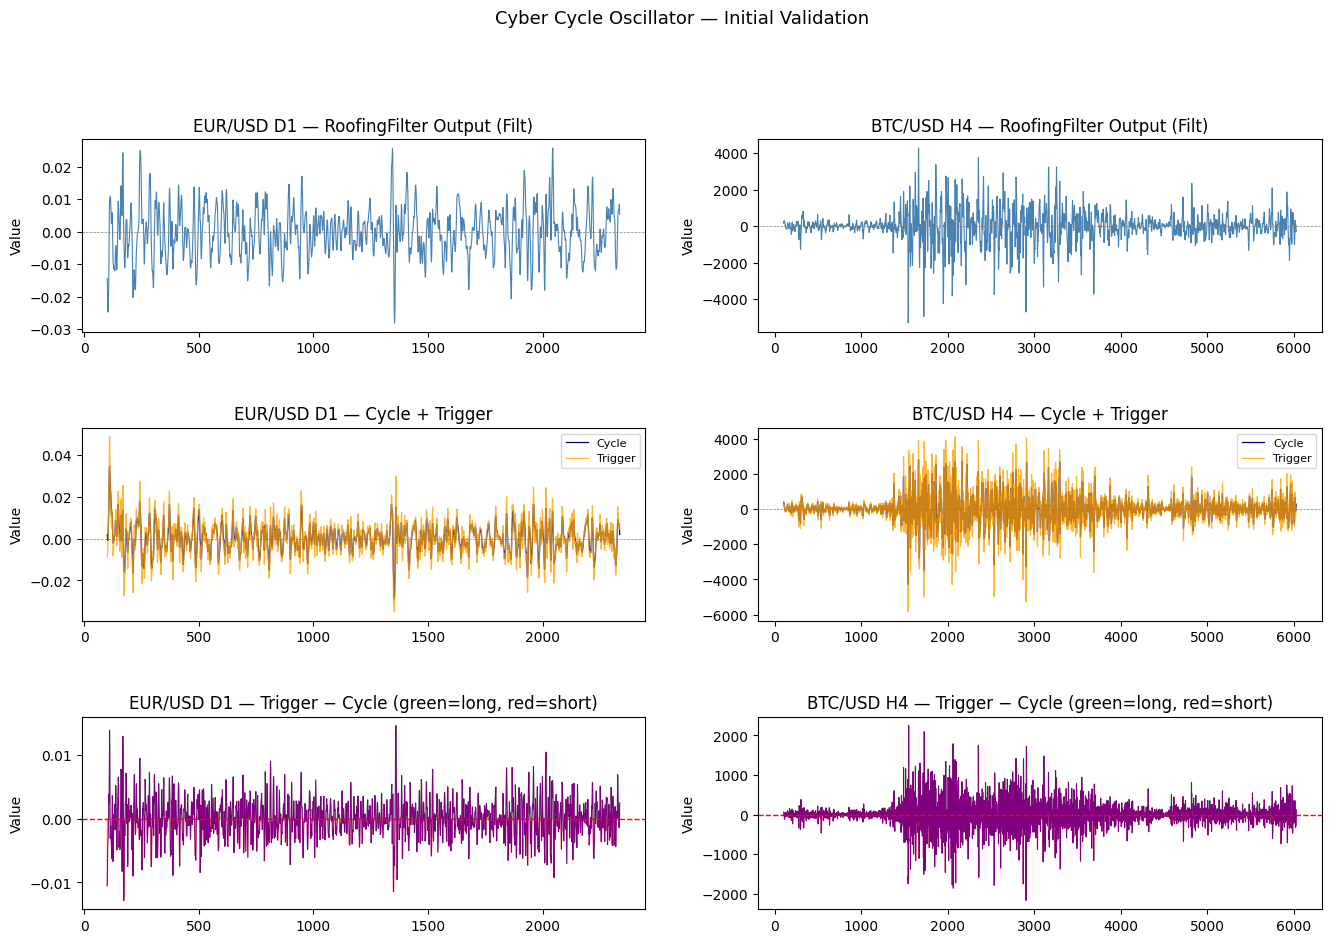

Saved: CyberCycle_validation.png


In [3]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5)

for col, (name, df) in enumerate([('EUR/USD D1', eurusd), ('BTC/USD H4', btcusd)]):
    bars = df['bar']
    
    # Panel 1: RoofingFilter output
    ax1 = fig.add_subplot(gs[0, col])
    ax1.plot(bars, df['filt'], color='steelblue', linewidth=0.8)
    ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax1.set_title(f'{name} — RoofingFilter Output (Filt)')
    ax1.set_ylabel('Value')
    
    # Panel 2: Cycle + Trigger
    ax2 = fig.add_subplot(gs[1, col])
    ax2.plot(bars, df['cycle'],   color='navy',   linewidth=0.9, label='Cycle')
    ax2.plot(bars, df['trigger'], color='orange', linewidth=0.9, label='Trigger', alpha=0.8)
    ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax2.set_title(f'{name} — Cycle + Trigger')
    ax2.set_ylabel('Value')
    ax2.legend(fontsize=8)
    
    # Panel 3: Trigger - Cycle (crossover signal)
    ax3 = fig.add_subplot(gs[2, col])
    diff = df['trigger'] - df['cycle']
    ax3.plot(bars, diff, color='purple', linewidth=0.7)
    ax3.axhline(0, color='red', linewidth=1.0, linestyle='--')
    ax3.fill_between(bars, diff, 0, where=(diff > 0), color='green', alpha=0.3)
    ax3.fill_between(bars, diff, 0, where=(diff < 0), color='red',   alpha=0.3)
    ax3.set_title(f'{name} — Trigger − Cycle (green=long, red=short)')
    ax3.set_ylabel('Value')

plt.suptitle('Cyber Cycle Oscillator — Initial Validation', fontsize=13, y=1.01)
plt.savefig('CyberCycle_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: CyberCycle_validation.png")

In [4]:
def find_crossovers(df):
    """Returns indices where Trigger crosses Cycle."""
    diff = df['trigger'] - df['cycle']
    # +1 = trigger crosses above cycle (long signal)
    # -1 = trigger crosses below cycle (short signal)
    signals = np.sign(diff).diff().fillna(0)
    long_signals  = df.index[signals > 0].tolist()
    short_signals = df.index[signals < 0].tolist()
    return long_signals, short_signals

for name, df in [('EUR/USD D1', eurusd), ('BTC/USD H4', btcusd)]:
    long_idx, short_idx = find_crossovers(df)
    total_bars    = len(df)
    total_signals = len(long_idx) + len(short_idx)
    avg_freq      = total_bars / total_signals if total_signals > 0 else 0

    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Total bars:        {total_bars}")
    print(f"  Long signals:      {len(long_idx)}")
    print(f"  Short signals:     {len(short_idx)}")
    print(f"  Total crossovers:  {total_signals}")
    print(f"  Avg bars/signal:   {avg_freq:.1f}")
    print()

  EUR/USD D1
  Total bars:        2236
  Long signals:      260
  Short signals:     259
  Total crossovers:  519
  Avg bars/signal:   4.3

  BTC/USD H4
  Total bars:        5927
  Long signals:      662
  Short signals:     663
  Total crossovers:  1325
  Avg bars/signal:   4.5



In [5]:
# EUR/USD 2022 downtrend: strong USD rally, EUR/USD fell ~1.13 → ~0.97
# Data starts bar 101 = Jan 2015. At ~252 bars/year:
# 2022 ≈ bars 1865-2116

trend_start = 1865
trend_end   = 2116

eurusd_trend = eurusd[
    (eurusd['bar'] >= trend_start) & 
    (eurusd['bar'] <= trend_end)
].copy()

eurusd_cycle = eurusd[
    (eurusd['bar'] < trend_start)
].copy()

def count_crossovers(df):
    diff    = df['trigger'] - df['cycle']
    signals = np.sign(diff).diff().fillna(0)
    return (signals != 0).sum()

trend_signals = count_crossovers(eurusd_trend)
cycle_signals = count_crossovers(eurusd_cycle)

trend_bars  = len(eurusd_trend)
cycle_bars  = len(eurusd_cycle)

trend_rate  = trend_bars  / trend_signals if trend_signals  > 0 else 0
cycle_rate  = cycle_bars  / cycle_signals if cycle_signals  > 0 else 0

print("EUR/USD — Trend Mode vs Cycle Mode Signal Frequency")
print("="*52)
print(f"  2022 downtrend (bars {trend_start}-{trend_end}):")
print(f"    Bars:            {trend_bars}")
print(f"    Crossovers:      {trend_signals}")
print(f"    Avg bars/signal: {trend_rate:.1f}  ← trend mode (want HIGH)")
print()
print(f"  Pre-2022 period (bars 101-{trend_start-1}):")
print(f"    Bars:            {cycle_bars}")
print(f"    Crossovers:      {cycle_signals}")
print(f"    Avg bars/signal: {cycle_rate:.1f}  ← mixed mode (baseline)")

EUR/USD — Trend Mode vs Cycle Mode Signal Frequency
  2022 downtrend (bars 1865-2116):
    Bars:            252
    Crossovers:      51
    Avg bars/signal: 4.9  ← trend mode (want HIGH)

  Pre-2022 period (bars 101-1864):
    Bars:            1764
    Crossovers:      410
    Avg bars/signal: 4.3  ← mixed mode (baseline)


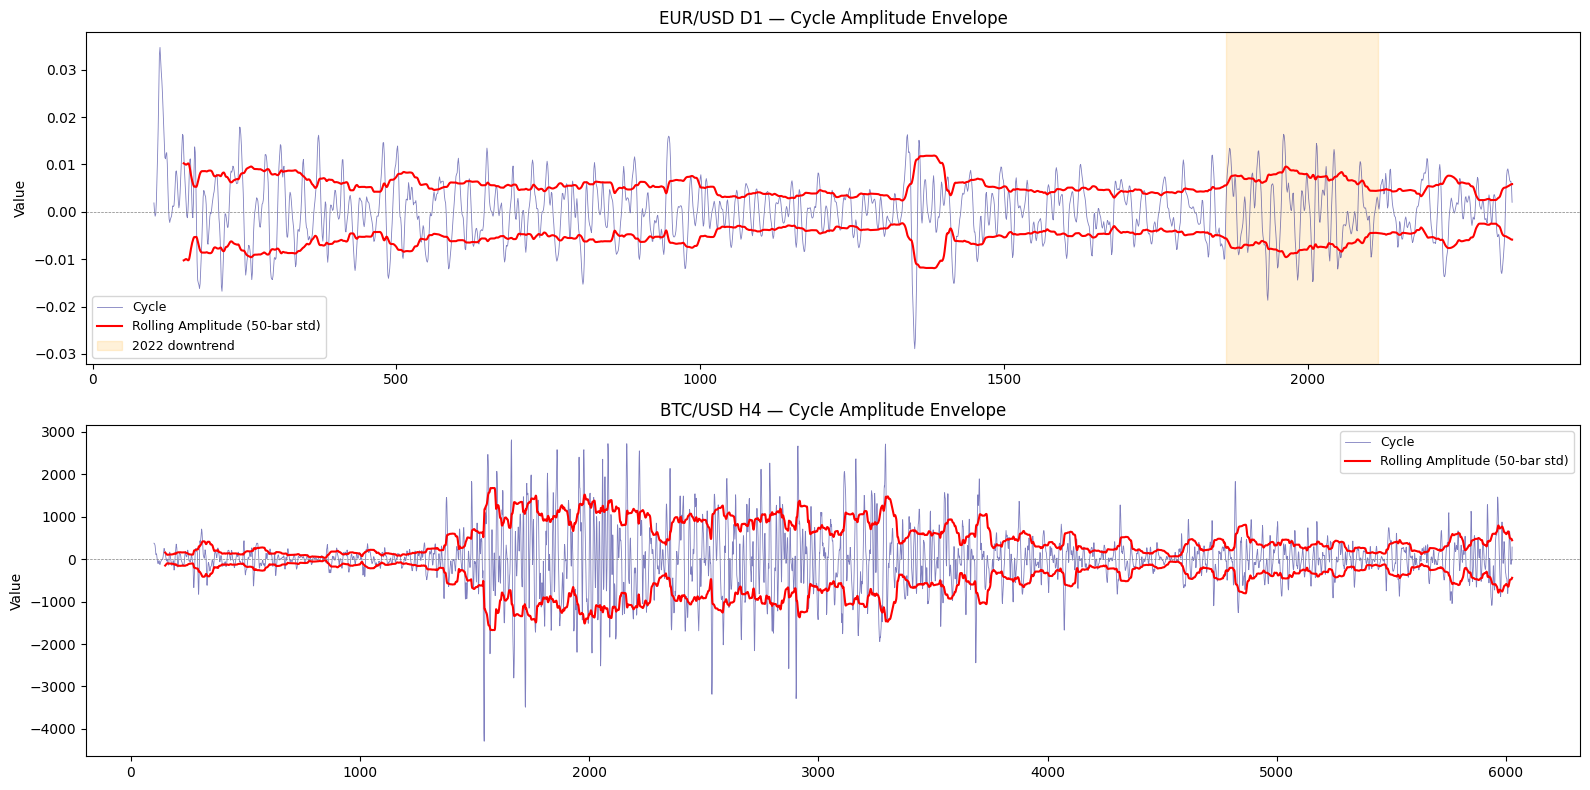

Saved: CyberCycle_amplitude.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for ax, (name, df) in zip(axes, [('EUR/USD D1', eurusd), ('BTC/USD H4', btcusd)]):
    bars = df['bar']
    
    # Rolling amplitude (std over 50-bar window)
    rolling_amp = df['cycle'].rolling(50).std()
    
    ax.plot(bars, df['cycle'],   color='navy',   linewidth=0.6, alpha=0.5, label='Cycle')
    ax.plot(bars, rolling_amp,   color='red',    linewidth=1.5, label='Rolling Amplitude (50-bar std)')
    ax.plot(bars, -rolling_amp,  color='red',    linewidth=1.5)
    ax.axhline(0, color='gray',  linewidth=0.5,  linestyle='--')
    
    if name == 'EUR/USD D1':
        ax.axvspan(1865, 2116, alpha=0.15, color='orange', label='2022 downtrend')
    
    ax.set_title(f'{name} — Cycle Amplitude Envelope')
    ax.set_ylabel('Value')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('CyberCycle_amplitude.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: CyberCycle_amplitude.png")

In [7]:
print("=" * 60)
print("  CYBER CYCLE — VALIDATION SUMMARY")
print("=" * 60)

print("""
INDICATOR PROPERTIES
  Type:          2nd-order IIR resonant bandpass oscillator
  Input:         RoofingFilter output (HP=48, SS=10)
  Parameters:    alpha=0.07, Trigger = 2*Cyc[1] - Cyc[3]
  Warmup:        100 bars

EUR/USD D1 (2015-2024, 2236 bars)
  Cycle mean:          0.00023  (centered on zero ✓)
  Cycle std:           0.00624
  Cycle range:         -0.0289 to +0.0347
  Signal frequency:    4.3 bars/signal  (high — needs MAMA gate)
  Trend mode signals:  4.9 bars/signal  (2022 downtrend)
  Amplitude:           Stable ±0.007-0.010 throughout ✓
  AGC needed:          No — amplitude consistent

BTC/USD H4 (2020-2024, 5927 bars)
  Cycle mean:          +0.42   (near-zero ✓)
  Cycle std:           653.67
  Cycle range:         -4288 to +2804
  Signal frequency:    4.5 bars/signal
  Amplitude:           Varies 10x across regimes ✗
  AGC needed:          YES — mandatory before strategy use

KEY FINDINGS
  1. Oscillator is correctly centered on zero for both assets ✓
  2. Cycle does NOT self-suppress in trend mode — needs external
     trend gate (MAMA/FAMA spread as regime signal) ✓ expected
  3. Signal frequency (4.3 bars) is high for D1 use — Trigger
     crossovers are noisy; consider zero-line crosses instead
  4. EUR/USD amplitude stable and reliable across 9 years ✓
  5. BTC amplitude scale varies 10x — AGC normalization required
     before any BTC strategy use

RECOMMENDATION
  APPROVED for library with conditions:
  - EUR/USD D1: use with MAMA/FAMA trend gate
  - BTC H4: normalize output before use (AGC or rolling zscore)
""")

  CYBER CYCLE — VALIDATION SUMMARY

INDICATOR PROPERTIES
  Type:          2nd-order IIR resonant bandpass oscillator
  Input:         RoofingFilter output (HP=48, SS=10)
  Parameters:    alpha=0.07, Trigger = 2*Cyc[1] - Cyc[3]
  Warmup:        100 bars

EUR/USD D1 (2015-2024, 2236 bars)
  Cycle mean:          0.00023  (centered on zero ✓)
  Cycle std:           0.00624
  Cycle range:         -0.0289 to +0.0347
  Signal frequency:    4.3 bars/signal  (high — needs MAMA gate)
  Trend mode signals:  4.9 bars/signal  (2022 downtrend)
  Amplitude:           Stable ±0.007-0.010 throughout ✓
  AGC needed:          No — amplitude consistent

BTC/USD H4 (2020-2024, 5927 bars)
  Cycle mean:          +0.42   (near-zero ✓)
  Cycle std:           653.67
  Cycle range:         -4288 to +2804
  Signal frequency:    4.5 bars/signal
  Amplitude:           Varies 10x across regimes ✗
  AGC needed:          YES — mandatory before strategy use

KEY FINDINGS
  1. Oscillator is correctly centered on zero fo